Importing the libraries

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
import numpy as np
import matplotlib.pyplot as plt
import random

Loading the Dataset

In [30]:
X_train=np.loadtxt('input.csv',delimiter=',')
Y_train=np.loadtxt('labels.csv',delimiter=',')

X_test=np.loadtxt('input_test.csv',delimiter=',')
Y_test=np.loadtxt('labels_test.csv',delimiter=',')

In [31]:
X_train=X_train.reshape(len(X_train),100,100,3)
Y_train=Y_train.reshape(len(Y_train),1)
X_test=X_test.reshape(len(X_test),100,100,3)
Y_test=Y_test.reshape(len(Y_test),1)
X_train=X_train/255.0
X_test=X_test/255.0

In [32]:
print("Shape of X_Train:",X_train.shape)
print("Shape of Y_Train:",Y_train.shape)
print("Shape of X_test:",X_test.shape)
print("Shape of Y_Test:",Y_train.shape)

Shape of X_Train: (2000, 100, 100, 3)
Shape of Y_Train: (2000, 1)
Shape of X_test: (400, 100, 100, 3)
Shape of Y_Test: (2000, 1)


shape: (100, 100, 3)
dtype: float64
min/max: 0.0 0.792156862745098


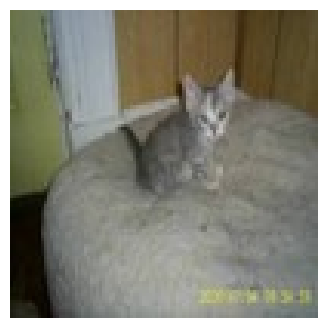

In [33]:
idx = random.randint(0, len(X_train) - 1)
img = X_train[idx]

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min/max:", img.min(), img.max())

plt.figure(figsize=(4, 4))
plt.imshow(img)          # no cmap for RGB images
plt.axis("off")
plt.show()

Model

In [34]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)),
    MaxPooling2D((2,2)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
]
)

c:\Users\PatelDharmikkumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid')
)

In [36]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [42]:
model.fit(X_train,Y_train,epochs=5,batch_size=64)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6970 - loss: 0.5908
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7075 - loss: 0.5534
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7490 - loss: 0.5204
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7645 - loss: 0.4900
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7895 - loss: 0.4585


In [43]:
model.evaluate(X_test,Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7325 - loss: 0.5646


[0.5646000504493713, 0.7325000166893005]

Making Prediction

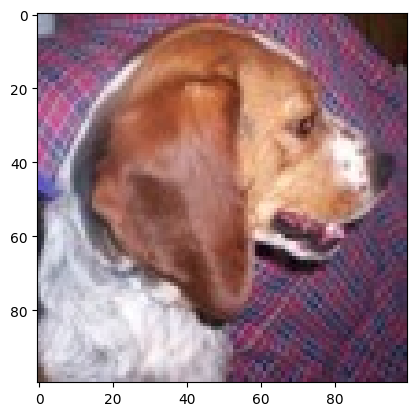

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Label: dog


In [45]:
idx2=random.randint(0, len(Y_test) - 1)
plt.imshow(X_test[idx2,:])
plt.show()
y_pred=model.predict(X_test[idx2,:].reshape(1,100,100,3))
y_pred = y_pred > 0.5
if(y_pred==0):
    pred="dog"
else:
    pred="cat"

print("Predicted Label:",pred)